In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("PyTorch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [3]:
ruta = '/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab02/train.csv'

data = pd.read_csv(ruta)

data.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
print("Dimensiones:", data.shape)

print("\nVariable objetivo:")
print("critical_temp" in data.columns)

print("\nPrimeras columnas:")
print(data.columns[:10].tolist())

print("\nÚltima columna:")
print(data.columns[-1])

Dimensiones: (21263, 82)

Variable objetivo:
True

Primeras columnas:
['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass']

Última columna:
critical_temp


In [5]:
X = data.drop(
    columns=['critical_temp']
).values.astype(np.float32)

y = data[
    ['critical_temp']
].values.astype(np.float32)

print("X:", X.shape)
print("y:", y.shape)

X: (21263, 81)
y: (21263, 1)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Val X:", X_val.shape)
print("Val y:", y_val.shape)

Train X: (17010, 81)
Train y: (17010, 1)
Val X: (4253, 81)
Val y: (4253, 1)


In [7]:
mu = X_train.mean(axis=0)

sigma = X_train.std(axis=0)

sigma[sigma == 0] = 1

X_train_norm = (
    X_train - mu
) / sigma

X_val_norm = (
    X_val - mu
) / sigma

print("Normalización completada")

Normalización completada


In [8]:
class DatasetPersonalizado(
    torch.utils.data.Dataset
):

    def __init__(self, X, Y):

        self.X = torch.from_numpy(
            X
        ).float()

        self.Y = torch.from_numpy(
            Y
        ).float()


    def __len__(self):

        return len(self.X)


    def __getitem__(self, ix):

        return (
            self.X[ix],
            self.Y[ix]
        )

In [9]:
dataset = {

    'train': DatasetPersonalizado(
        X_train_norm,
        y_train
    ),

    'val': DatasetPersonalizado(
        X_val_norm,
        y_val
    )
}

print(
    "Train:",
    len(dataset['train'])
)

print(
    "Validación:",
    len(dataset['val'])
)

Train: 17010
Validación: 4253


In [10]:
dataloader = {

    'train': torch.utils.data.DataLoader(
        dataset['train'],
        batch_size=64,
        shuffle=True
    ),

    'val': torch.utils.data.DataLoader(
        dataset['val'],
        batch_size=64,
        shuffle=False
    )
}

In [11]:
x_b, y_b = next(
    iter(dataloader['train'])
)

print(
    "X batch:",
    x_b.shape
)

print(
    "y batch:",
    y_b.shape
)

X batch: torch.Size([64, 81])
y batch: torch.Size([64, 1])


In [12]:
class ModeloRegresionMultiple(
    torch.nn.Module
):

    def __init__(self):

        super(
            ModeloRegresionMultiple,
            self
        ).__init__()

        self.linear = torch.nn.Linear(
            81,
            1
        )


    def forward(self, x):

        return self.linear(x)

In [13]:
model = ModeloRegresionMultiple().to(
    device
)

criterion = torch.nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

print(model)

ModeloRegresionMultiple(
  (linear): Linear(in_features=81, out_features=1, bias=True)
)


In [14]:
def fit(
    model,
    dataloader,
    optimizer,
    epochs=300,
    log_each=50
):

    criterion = torch.nn.MSELoss()

    train_loss = []
    val_loss = []

    best_loss = float('inf')


    for e in range(
        1,
        epochs + 1
    ):

        # ENTRENAMIENTO

        model.train()

        _train_loss = []


        for x_b, y_b in dataloader['train']:

            x_b = x_b.to(device)

            y_b = y_b.to(device)


            y_pred = model(x_b)

            loss = criterion(
                y_pred,
                y_b
            )


            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


            _train_loss.append(
                loss.item()
            )


        train_loss.append(
            np.mean(_train_loss)
        )


        # VALIDACIÓN

        model.eval()

        _val_loss = []


        with torch.no_grad():

            for x_b, y_b in dataloader['val']:

                x_b = x_b.to(device)

                y_b = y_b.to(device)


                y_pred = model(x_b)

                loss = criterion(
                    y_pred,
                    y_b
                )


                _val_loss.append(
                    loss.item()
                )


        val_loss.append(
            np.mean(_val_loss)
        )


        if val_loss[-1] < best_loss:

            best_loss = val_loss[-1]

            torch.save(
                model.state_dict(),
                'mejor_modelo_lab02.pt'
            )


        if not e % log_each:

            print(
                f"Epoch {e}/{epochs} "
                f"loss {train_loss[-1]:.5f} "
                f"val_loss {val_loss[-1]:.5f}"
            )


    model.load_state_dict(
        torch.load(
            'mejor_modelo_lab02.pt',
            map_location=device
        )
    )


    return {
        'epoch':
            list(
                range(
                    1,
                    len(train_loss) + 1
                )
            ),

        'loss':
            train_loss,

        'val_loss':
            val_loss
    }

In [15]:
model = ModeloRegresionMultiple().to(
    device
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

hist = fit(
    model,
    dataloader,
    optimizer,
    epochs=300,
    log_each=50
)

Epoch 50/300 loss 344.83185 val_loss 331.12221
Epoch 100/300 loss 335.84658 val_loss 323.31665
Epoch 150/300 loss 330.59141 val_loss 318.51935
Epoch 200/300 loss 327.13137 val_loss 316.02727
Epoch 250/300 loss 324.57825 val_loss 313.39022
Epoch 300/300 loss 322.65928 val_loss 312.10501


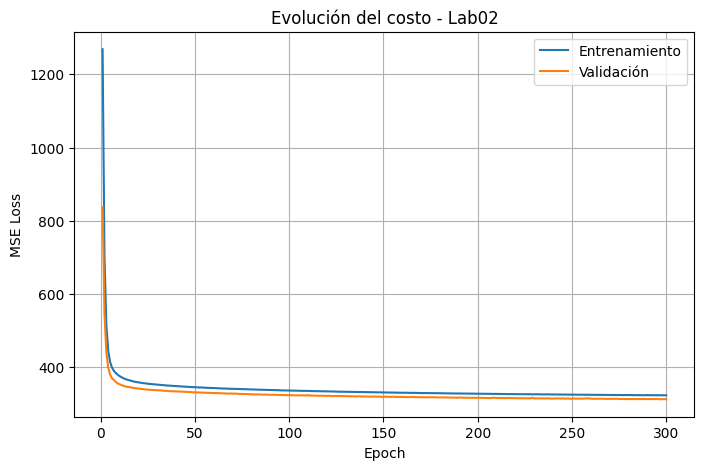

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist['epoch'],
    hist['loss'],
    label='Entrenamiento'
)

plt.plot(
    hist['epoch'],
    hist['val_loss'],
    label='Validación'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Evolución del costo - Lab02')

plt.legend()
plt.grid()

plt.show()

In [17]:
model.eval()

predicciones = []
valores_reales = []

with torch.no_grad():

    for x_b, y_b in dataloader['val']:

        x_b = x_b.to(device)

        y_pred = model(x_b)

        predicciones.extend(
            y_pred.cpu().numpy()
        )

        valores_reales.extend(
            y_b.numpy()
        )

y_pred = np.array(
    predicciones
).flatten()

y_real = np.array(
    valores_reales
).flatten()

In [18]:
mse = mean_squared_error(
    y_real,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_real,
    y_pred
)

r2 = r2_score(
    y_real,
    y_pred
)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 311.7697448730469
RMSE: 17.657002714873407
MAE : 13.423968315124512
R²  : 0.7291502952575684


In [19]:
for i in range(10):

    print(
        f"Real: {y_real[i]:.2f} "
        f"→ Predicho: {y_pred[i]:.2f}"
    )

Real: 6.40 → Predicho: 8.08
Real: 91.20 → Predicho: 78.47
Real: 38.00 → Predicho: 59.56
Real: 19.00 → Predicho: 30.18
Real: 11.00 → Predicho: 7.21
Real: 62.00 → Predicho: 61.43
Real: 84.00 → Predicho: 62.29
Real: 50.10 → Predicho: 74.99
Real: 35.00 → Predicho: 32.72
Real: 8.02 → Predicho: 22.08


In [20]:
import os

carpeta = (
    '/content/drive/MyDrive/'
    'Colab Notebooks/'
    'Machine Learning Soto/'
    'LabPyTorch/'
    'Lab02'
)

os.makedirs(
    carpeta,
    exist_ok=True
)

PATH = os.path.join(
    carpeta,
    'lab02_checkpoint.pt'
)

torch.save(
    {
        'model_state_dict':
            model.state_dict(),

        'optimizer_state_dict':
            optimizer.state_dict(),

        'mu':
            mu,

        'sigma':
            sigma,

        'mse':
            mse,

        'rmse':
            rmse,

        'mae':
            mae,

        'r2':
            r2
    },

    PATH
)

print("Modelo guardado en:")
print(PATH)

Modelo guardado en:
/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/LabPyTorch/Lab02/lab02_checkpoint.pt


In [21]:
print(
    "Existe:",
    os.path.exists(PATH)
)

Existe: True


In [22]:
checkpoint = torch.load(
    PATH,
    map_location=device,
    weights_only=False
)

print("Checkpoint cargado")

Checkpoint cargado


In [23]:
modelo_cargado = (
    ModeloRegresionMultiple()
    .to(device)
)

modelo_cargado.load_state_dict(
    checkpoint[
        'model_state_dict'
    ]
)

modelo_cargado.eval()

print(
    "Modelo recuperado correctamente"
)

Modelo recuperado correctamente


In [24]:
print(
    "MSE :",
    checkpoint['mse']
)

print(
    "RMSE:",
    checkpoint['rmse']
)

print(
    "MAE :",
    checkpoint['mae']
)

print(
    "R²  :",
    checkpoint['r2']
)

MSE : 311.7697448730469
RMSE: 17.657002714873407
MAE : 13.423968315124512
R²  : 0.7291502952575684


In [25]:
print(
    "LABORATORIO 02 PYTORCH COMPLETADO"
)

print(
    "Dataset     : Superconductivity"
)

print(
    "Entradas    : 81 características"
)

print(
    "Salida      : critical_temp"
)

print(
    "Modelo      : Regresión lineal múltiple"
)

print(
    "Dataset     : OK"
)

print(
    "DataLoader  : OK"
)

print(
    "MSELoss     : OK"
)

print(
    "SGD         : OK"
)

print(
    "Métricas    : OK"
)

print(
    "Checkpoint  : OK"
)

LABORATORIO 02 PYTORCH COMPLETADO
Dataset     : Superconductivity
Entradas    : 81 características
Salida      : critical_temp
Modelo      : Regresión lineal múltiple
Dataset     : OK
DataLoader  : OK
MSELoss     : OK
SGD         : OK
Métricas    : OK
Checkpoint  : OK
